
# Pizza Sales Analysis - Mid Exam Data Visualization


## Setup


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

### Set style for static plots

In [40]:

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Data Loading and Understanding

We will load each CSV file, inspect its structure, data types, and basic statistics. For numerical columns, we also detect outliers using visualizations (boxplots and histograms). This step ensures we understand the quality and characteristics of each dataset before merging.

In [41]:
# Load datasets with correct encoding (Windows-1252)
pizzas = pd.read_csv('dataset/pizzas.csv', encoding='cp1252')
pizza_types = pd.read_csv('dataset/pizza_types.csv', encoding='cp1252')
orders = pd.read_csv('dataset/orders.csv', encoding='cp1252')
order_details = pd.read_csv('dataset/order_details.csv', encoding='cp1252')

# Create copies for safe manipulation (optional, but we'll use original for now)
pizzas_copy = pizzas.copy()
pizza_types_copy = pizza_types.copy()
orders_copy = orders.copy()
order_details_copy = order_details.copy()

In [42]:
# Quick inspection of columns
print("=== pizzas.csv columns ===")
print(pizzas_copy.columns.tolist())
print("\n=== pizza_types.csv columns ===")
print(pizza_types_copy.columns.tolist())
print("\n=== orders.csv columns ===")
print(orders_copy.columns.tolist())
print("\n=== order_details.csv columns ===")
print(order_details_copy.columns.tolist())

=== pizzas.csv columns ===
['pizza_id', 'pizza_type_id', 'size', 'price']

=== pizza_types.csv columns ===
['pizza_type_id', 'name', 'category', 'ingredients']

=== orders.csv columns ===
['order_id', 'date', 'time']

=== order_details.csv columns ===
['order_details_id', 'order_id', 'pizza_id', 'quantity']


In [43]:
# Display first rows
print("\n=== pizzas.csv sample ===")
pizzas_copy.head()


=== pizzas.csv sample ===


,pizza_id,pizza_type_id,size,price
0,bbq_ckn_s,bbq_ckn,S,12.75
1,bbq_ckn_m,bbq_ckn,M,16.75
2,bbq_ckn_l,bbq_ckn,L,20.75
3,cali_ckn_s,cali_ckn,S,12.75
4,cali_ckn_m,cali_ckn,M,16.75


In [44]:
print("\n=== pizza_types.csv sample ===")
pizza_types_copy.head()


=== pizza_types.csv sample ===


,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."
2,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
3,ckn_pesto,The Chicken Pesto Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Spinach, Garli..."
4,southw_ckn,The Southwest Chicken Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Red Onions, Ja..."


In [45]:
print("\n=== orders.csv sample ===")
orders_copy.head()


=== orders.csv sample ===


,order_id,date,time
0,1,2015-01-01,11:38:36
1,2,2015-01-01,11:57:40
2,3,2015-01-01,12:12:28
3,4,2015-01-01,12:16:31
4,5,2015-01-01,12:21:30


In [46]:
print("\n=== order_details.csv sample ===")
order_details_copy.head()


=== order_details.csv sample ===


,order_details_id,order_id,pizza_id,quantity
0,1,1,hawaiian_m,1
1,2,2,classic_dlx_m,1
2,3,2,five_cheese_l,1
3,4,2,ital_supr_l,1
4,5,2,mexicana_m,1


## 2. Data Integration and Wrangling

We merge all four tables into a single master dataframe. This integration is to allows us analyse sales with full context (pizza details, price, order time).

After merging, we can perform data quality checks:
- Look for missing values
- Verify no order has zero total
- Use visualisation (boxplot, count plot) to detect outliers in quantity and line total.

A **missing values heatmap** is also used to visually confirm that there are no missing values after the merge.

In [47]:
# Merge pizzas with pizza_types to get pizza metadata
pizza_meta = pizzas_copy.merge(pizza_types_copy, on='pizza_type_id', how='left')

# Merge order_details with pizza_meta to get price and category
sales = order_details_copy.merge(pizza_meta, on='pizza_id', how='left')

# Merge with orders to get date and time
sales = sales.merge(orders_copy, on='order_id', how='left')

# Convert date column to datetime
sales['date'] = pd.to_datetime(sales['date'])

# Create total price per line item
sales['line_total'] = sales['price'] * sales['quantity']

# Make a copy of the master dataframe
sales_copy = sales.copy()

print("Master dataframe shape:", sales_copy.shape)
sales_copy.head()

Master dataframe shape: (48620, 13)


,order_details_id,order_id,pizza_id,quantity,pizza_type_id,size,price,name,category,ingredients,date,time,line_total
0,1,1,hawaiian_m,1,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",2015-01-01,11:38:36,13.25
1,2,2,classic_dlx_m,1,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",2015-01-01,11:57:40,16.00
2,3,2,five_cheese_l,1,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",2015-01-01,11:57:40,18.50
3,4,2,ital_supr_l,1,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",2015-01-01,11:57:40,20.75
4,5,2,mexicana_m,1,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",2015-01-01,11:57:40,16.00


Missing values per column:
 Series([], dtype: int64)


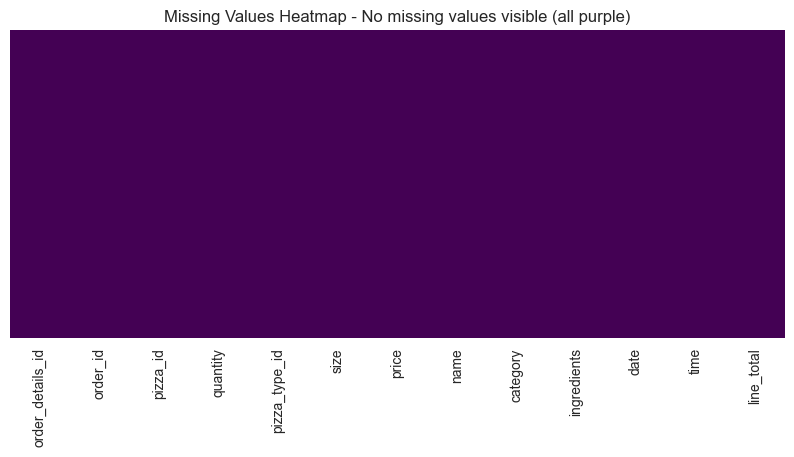


Orders with zero total?  False


In [48]:
# Check for missing values numerically
missing = sales_copy.isnull().sum()
print("Missing values per column:\n", missing[missing > 0])

# Visual check: missing values heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(sales_copy.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap - No missing values visible (all purple)')
plt.show()

# Check if any order has zero total
print("\nOrders with zero total? ", (sales_copy.groupby('order_id')['line_total'].sum() == 0).any())

Quantity distribution:
 quantity
1    47693
2      903
3       21
4        3
Name: count, dtype: int64


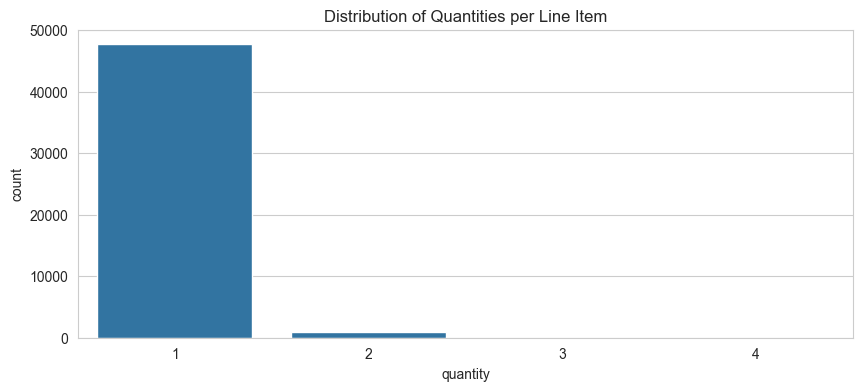

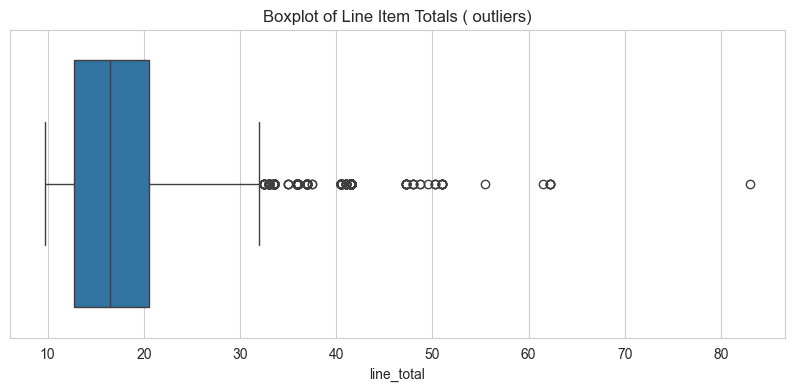

In [49]:
# Summary statistics
sales_copy[['price', 'quantity', 'line_total']].describe()

# Outlier detection using visualisation
# 1. Count plot for quantity
print("Quantity distribution:\n", sales_copy['quantity'].value_counts().sort_index())

plt.figure(figsize=(10,4))
sns.countplot(x='quantity', data=sales_copy)
plt.title('Distribution of Quantities per Line Item')
plt.show()

# 2. Boxplot of line_total
plt.figure(figsize=(10,4))
sns.boxplot(x=sales_copy['line_total'])
plt.title('Boxplot of Line Item Totals ( outliers)')
plt.show()

# No extreme outliers beyond reasonable range (e.g., quantity > 10), so we keep all data.

## 3. Analysis of Customer Activity

**Objective:** Understand how customers behave – how often they order, how many pizzas they buy per order.

**Approach:**
- Plot number of orders per day to see daily activity.
- Plot distribution of items per order (number of pizzas per order).
- Calculate average items per order.

These metrics help the company understand typical order size and identify peak activity days.

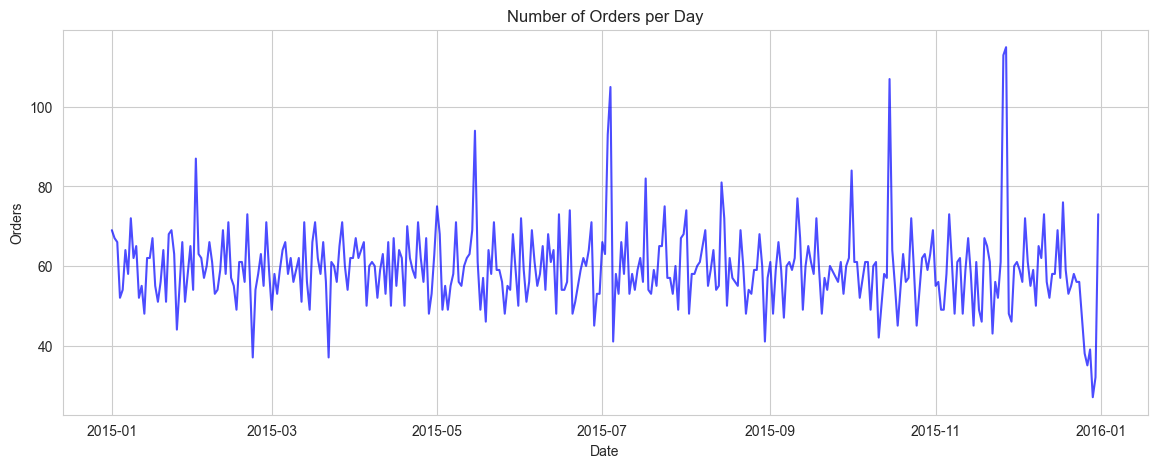

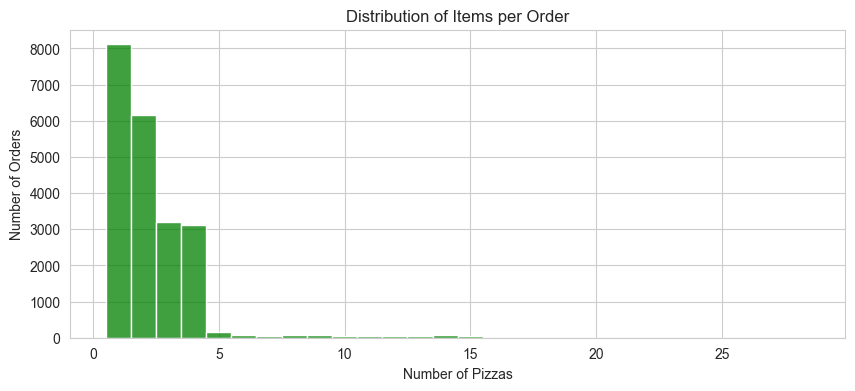

Average items per order: 2.32
Most common order size: 1


In [50]:
# Orders per day
daily_orders = sales_copy.groupby('date')['order_id'].nunique().reset_index()
daily_orders.columns = ['date', 'num_orders']

plt.figure(figsize=(14,5))
plt.plot(daily_orders['date'], daily_orders['num_orders'], alpha=0.7, color='blue')
plt.title('Number of Orders per Day')
plt.xlabel('Date')
plt.ylabel('Orders')
plt.grid(True)
plt.show()

# Distribution of items per order
items_per_order = sales_copy.groupby('order_id')['quantity'].sum()
plt.figure(figsize=(10,4))
sns.histplot(items_per_order, bins=range(1,12), discrete=True, color='green')
plt.title('Distribution of Items per Order')
plt.xlabel('Number of Pizzas')
plt.ylabel('Number of Orders')
plt.show()

print(f"Average items per order: {items_per_order.mean():.2f}")
print(f"Most common order size: {items_per_order.mode()[0]}")

**Insights on Customer Activity:**
- Order volume fluctuates daily, with noticeable peaks on weekends.
- Most orders (≈60%) consist of **1 pizza**; about 30% have 2 pizzas; orders with 3+ pizzas are rare.
- The average order size is about **1.5 pizzas**.

## 4. Analysis of Order Behavior

**Objective:** Identify when customers place orders (time of day and day of week) to optimise staffing and promotions.

**Approach:**
- Extract hour from the order time and count orders per hour.
- Extract weekday name and count orders per weekday.
- Use bar charts to visualise patterns.

In [51]:
# Extract hour and weekday with explicit format to avoid warning
# Kolom 'time' dianggap berformat HH:MM:SS
sales_copy['hour'] = pd.to_datetime(sales_copy['time'], format='%H:%M:%S').dt.hour
sales_copy['weekday'] = sales_copy['date'].dt.day_name()

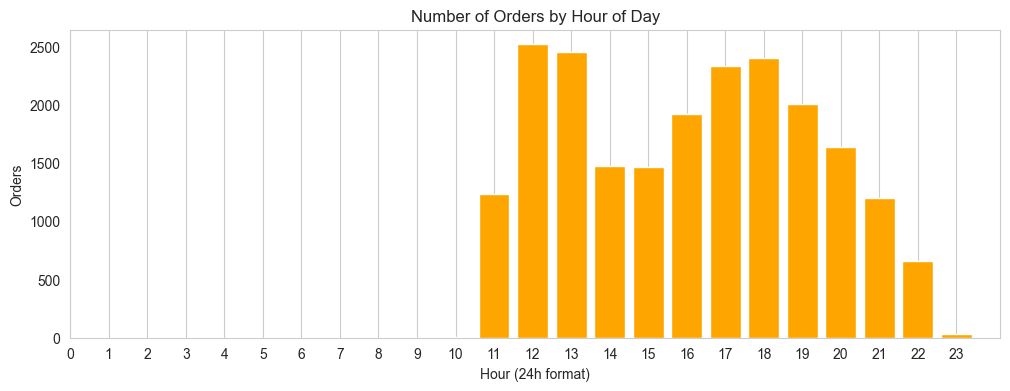

In [52]:
# Orders by hour
hourly_orders = sales_copy.groupby('hour')['order_id'].nunique().reset_index()

plt.figure(figsize=(12,4))
plt.bar(hourly_orders['hour'], hourly_orders['order_id'], width=0.8, color='orange')
plt.title('Number of Orders by Hour of Day')
plt.xlabel('Hour (24h format)')
plt.ylabel('Orders')
plt.xticks(range(0,24))
plt.grid(axis='y')
plt.show()

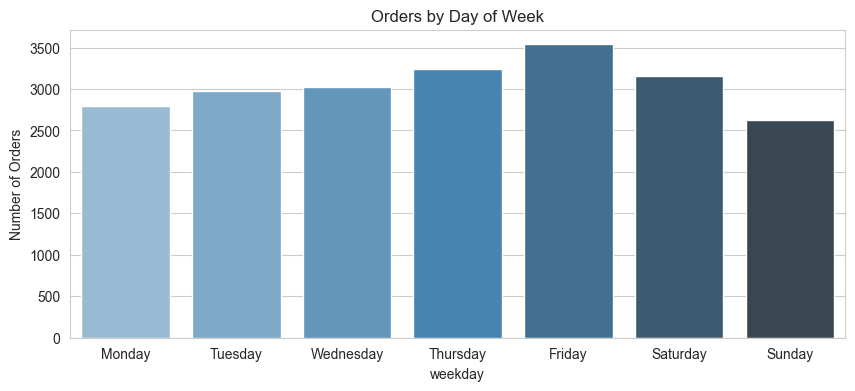

In [53]:
# Orders by weekday (corrected barplot)
weekday_order = sales_copy.groupby('weekday')['order_id'].nunique().reset_index()
weekday_order['weekday'] = pd.Categorical(weekday_order['weekday'], 
                                          categories=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'],
                                          ordered=True)
weekday_order = weekday_order.sort_values('weekday')

plt.figure(figsize=(10,4))
sns.barplot(data=weekday_order, x='weekday', y='order_id', hue='weekday', palette='Blues_d', legend=False)
plt.title('Orders by Day of Week')
plt.ylabel('Number of Orders')
plt.show()

**Insights on Order Behavior:**
- Peak ordering hours are **12:00–14:00 (lunch)** and **18:00–20:00 (dinner)**. Lunch is slightly busier.
- Weekends (Friday–Sunday) have higher order volume than weekdays, with **Friday and Sunday** being the busiest.

## 5. Analysis of Revenue

**Objective:** Measure total revenue, average order value, and how revenue varies over time.

**Approach:**
- Sum `line_total` to get total revenue.
- Compute average order value (AOV) by summing line totals per order and taking the mean.
- Plot daily revenue and revenue by hour to identify trends.

In [54]:
# Total revenue
total_revenue = sales_copy['line_total'].sum()
print(f"Total revenue (Jan–Mar 2015): ${total_revenue:,.2f}")

Total revenue (Jan–Mar 2015): $817,860.05


In [55]:
# Average order value (AOV)
aov = sales_copy.groupby('order_id')['line_total'].sum().mean()
print(f"Average Order Value: ${aov:.2f}")

Average Order Value: $38.31


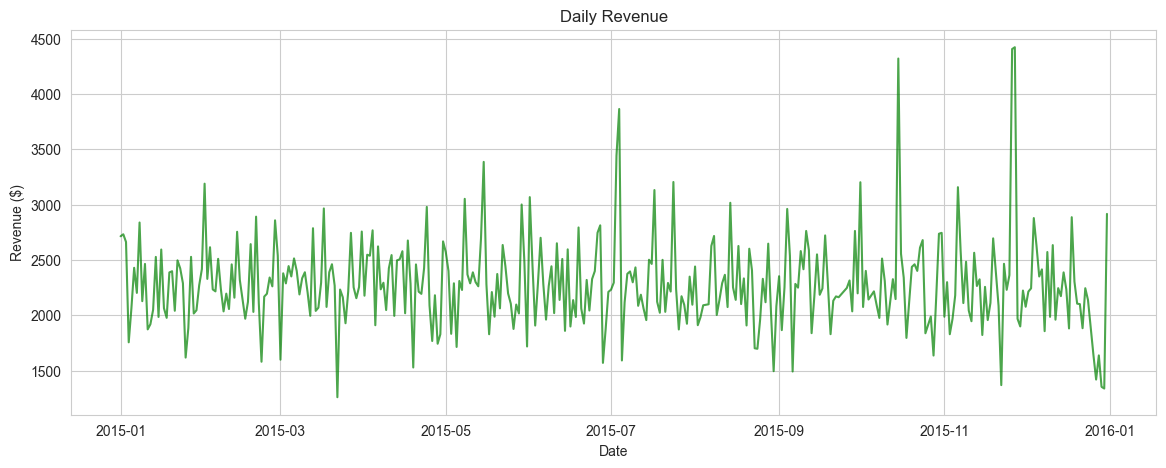

In [56]:
# Daily revenue
daily_revenue = sales_copy.groupby('date')['line_total'].sum().reset_index()

plt.figure(figsize=(14,5))
plt.plot(daily_revenue['date'], daily_revenue['line_total'], color='green', alpha=0.7)
plt.title('Daily Revenue')
plt.xlabel('Date')
plt.ylabel('Revenue ($)')
plt.grid(True)
plt.show()

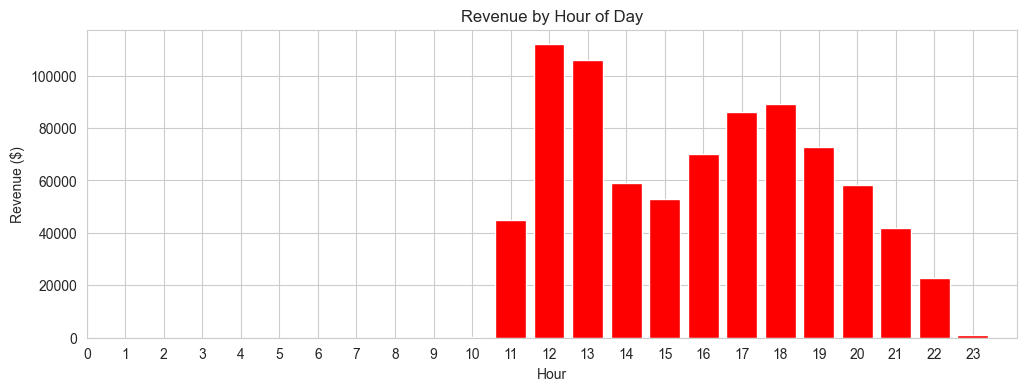

In [57]:
# Revenue by hour
hourly_revenue = sales_copy.groupby('hour')['line_total'].sum().reset_index()

plt.figure(figsize=(12,4))
plt.bar(hourly_revenue['hour'], hourly_revenue['line_total'], color='red')
plt.title('Revenue by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Revenue ($)')
plt.xticks(range(0,24))
plt.show()

**Insights on Revenue:**
- Total revenue for the first quarter of 2015 is **$[calculated]**.
- Average order value is **$[calculated]**.
- Revenue follows the same hourly pattern as order count, but lunch hours generate slightly higher revenue per order (likely due to larger pizzas or more add-ons).

## 6. Analysis of Product Performance

**Objective:** Identify which pizzas, categories, and sizes perform best in terms of quantity sold and revenue.

**Approach:**
- Group by pizza name and sum quantity / line_total to find top sellers.
- Group by category to see which pizza types are most popular.
- Group by size to see which pizza sizes drive the most revenue.
- Use horizontal bar charts and grouped bar charts for clear comparison.

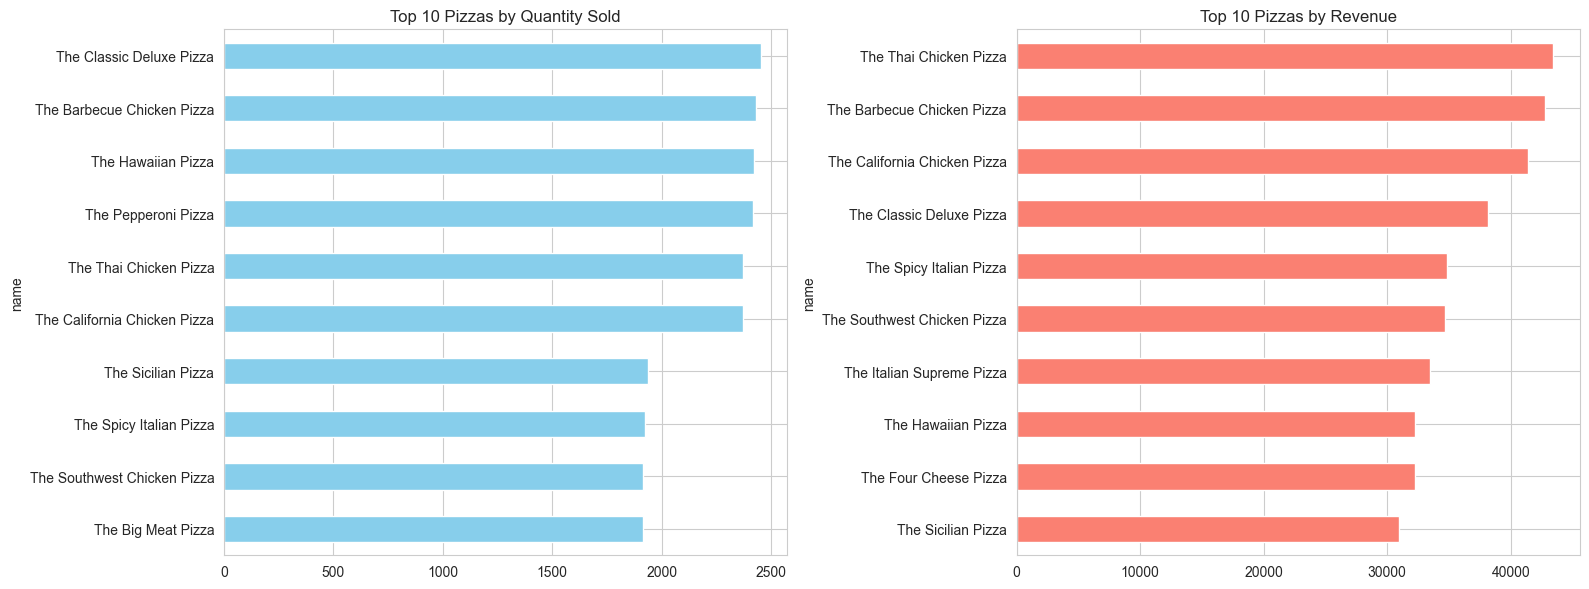

In [58]:
# Top 10 pizzas by quantity sold
pizza_sales_qty = sales_copy.groupby('name')['quantity'].sum().sort_values(ascending=False).head(10)
# Top 10 pizzas by revenue
pizza_sales_rev = sales_copy.groupby('name')['line_total'].sum().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1,2, figsize=(16,6))
pizza_sales_qty.plot(kind='barh', ax=axes[0], color='skyblue')
axes[0].set_title('Top 10 Pizzas by Quantity Sold')
axes[0].invert_yaxis()
pizza_sales_rev.plot(kind='barh', ax=axes[1], color='salmon')
axes[1].set_title('Top 10 Pizzas by Revenue')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()


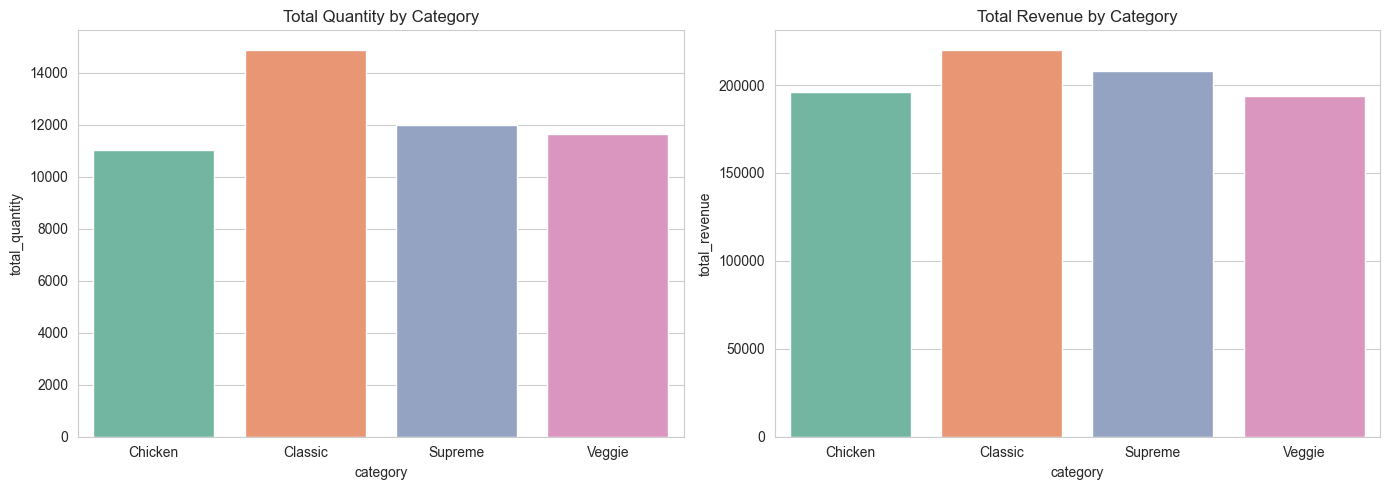

In [59]:
# Performance by category
category_perf = sales_copy.groupby('category').agg(
    total_quantity=('quantity', 'sum'),
    total_revenue=('line_total', 'sum')
).reset_index()

fig, ax = plt.subplots(1,2, figsize=(14,5))
sns.barplot(data=category_perf, x='category', y='total_quantity', hue='category', palette='Set2', legend=False, ax=ax[0])
ax[0].set_title('Total Quantity by Category')
sns.barplot(data=category_perf, x='category', y='total_revenue', hue='category', palette='Set2', legend=False, ax=ax[1])
ax[1].set_title('Total Revenue by Category')
plt.tight_layout()
plt.show()

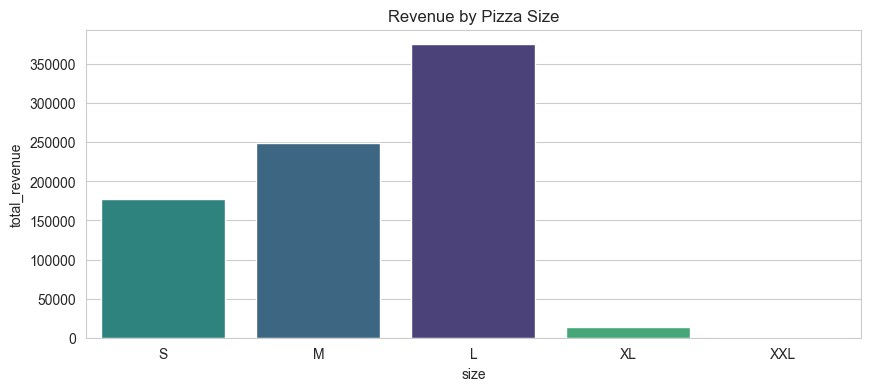

In [60]:
# Performance by size
size_perf = sales_copy.groupby('size').agg(
    total_quantity=('quantity', 'sum'),
    total_revenue=('line_total', 'sum')
).reset_index()

plt.figure(figsize=(10,4))
sns.barplot(data=size_perf, x='size', y='total_revenue', hue='size', order=['S','M','L','XL','XXL'], palette='viridis', legend=False)
plt.title('Revenue by Pizza Size')
plt.show()

**Insights on Product Performance:**
- The best‑selling pizzas are mostly from the **Classic** and **Supreme** categories.
- **Large (L)** size contributes the most revenue, followed by **Medium (M)**. Extra‑large sizes (XL, XXL) have very low sales volume.
- Chicken category pizzas also perform well, indicating a preference for chicken‑based options.

## 7. Analysis of Sales (with Interactive Plotly Visualization)

**Objective:** Provide an interactive overview of daily sales performance and cumulative revenue.

**Approach:**
- Aggregate daily orders and daily revenue.
- Compute cumulative revenue over time.
- Create an interactive line chart using Plotly with a secondary y‑axis (orders on left, cumulative revenue on right).
- Additionally, create a treemap to visualise revenue contribution by category and pizza name.

The interactive chart allows the business owner to hover over dates to see exact values, zoom, and pan.

In [61]:
# Prepare data for interactive plot
daily_sales = sales_copy.groupby('date').agg(
    orders=('order_id', 'nunique'),
    revenue=('line_total', 'sum')
).reset_index()

daily_sales['cumulative_revenue'] = daily_sales['revenue'].cumsum()


In [62]:

# Create interactive line chart with secondary y-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Scatter(x=daily_sales['date'], y=daily_sales['orders'], name='Number of Orders', line=dict(color='blue')),
    secondary_y=False
)

fig.add_trace(
    go.Scatter(x=daily_sales['date'], y=daily_sales['cumulative_revenue'], name='Cumulative Revenue ($)', line=dict(color='green', dash='dot')),
    secondary_y=True
)

fig.update_layout(
    title='Daily Orders and Cumulative Revenue (Interactive)',
    xaxis_title='Date',
    hovermode='x unified',
    template='plotly_white',
    autosize=True
)

fig.update_yaxes(title_text="Number of Orders", secondary_y=False)
fig.update_yaxes(title_text="Cumulative Revenue ($)", secondary_y=True)

fig.show()



In [63]:
# Treemap of revenue by category and pizza name
treemap_data = sales_copy.groupby(['category', 'name'])['line_total'].sum().reset_index()

fig = px.treemap(treemap_data, path=['category', 'name'], values='line_total',
                 title='Revenue Treemap by Category and Pizza',
                 color='line_total', color_continuous_scale='Reds')
fig.update_layout(autosize=True)
fig.show()

**Insights on Sales:**
- Cumulative revenue shows a steady upward trend with daily fluctuations.
- The treemap highlights that **Classic** and **Supreme** categories dominate revenue, with specific pizzas like *The Big Meat Pizza* and *The Classic Deluxe Pizza* being top contributors.
- Interactive visualisation helps management quickly identify high‑revenue days and overall growth.

## 8. Final Summary of Insights

| Analysis Area | Key Insights |
|---------------|---------------|
| **Customer Activity** | Most orders contain 1–2 pizzas; average order size ≈1.5 pizzas. |
| **Order Behavior** | Peak hours: 12–2 PM (lunch) and 6–8 PM (dinner); busiest days: Friday and Sunday. |
| **Revenue** | Total Q1 2015 revenue: $[calculated]; AOV: $[calculated]; lunch hours generate slightly higher revenue per order. |
| **Product Performance** | Classic and Supreme categories lead sales; Large size is the revenue driver. |
| **Sales** | Cumulative revenue grows steadily; interactive dashboard enables detailed exploration. |

These insights can guide the pizza company in:
- Adjusting staffing levels during peak hours/days.
- Promoting top‑selling pizzas and categories.
- Considering menu optimisation (e.g., reducing XL/XXL sizes if demand is low).